In [136]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('trimmed_imoveis.csv', sep=";")

# Remoção simples por percentil para estabilizar o modelo e gráficos
q_low = df['preco_brl'].quantile(0.01)
q_high = df['preco_brl'].quantile(0.98)

df = df[(df['preco_brl'] >= q_low) & (df['preco_brl'] <= q_high)].copy()

print(df.describe())

          preco_brl      area_m2     quartos   banheiros       vagas
count  2.800000e+02   280.000000  151.000000  215.000000  139.000000
mean   7.165904e+05   259.767857    2.980132    2.181395    2.395683
std    8.286916e+05   285.430354    1.145834    1.363622    2.736280
min    3.000000e+04    12.000000    1.000000    1.000000    1.000000
25%    2.100000e+05    57.000000    2.000000    1.000000    1.000000
50%    4.025000e+05   128.000000    3.000000    2.000000    2.000000
75%    9.600000e+05   350.000000    4.000000    3.000000    3.000000
max    6.248700e+06  1050.000000    6.000000    8.000000   30.000000
          preco_brl      area_m2     quartos   banheiros       vagas
count  2.710000e+02   271.000000  148.000000  210.000000  135.000000
mean   6.337487e+05   261.103321    2.986486    2.176190    2.400000
std    5.495487e+05   288.404802    1.142777    1.345702    2.767617
min    6.500000e+04    13.000000    1.000000    1.000000    1.000000
25%    2.100000e+05    57.000000  

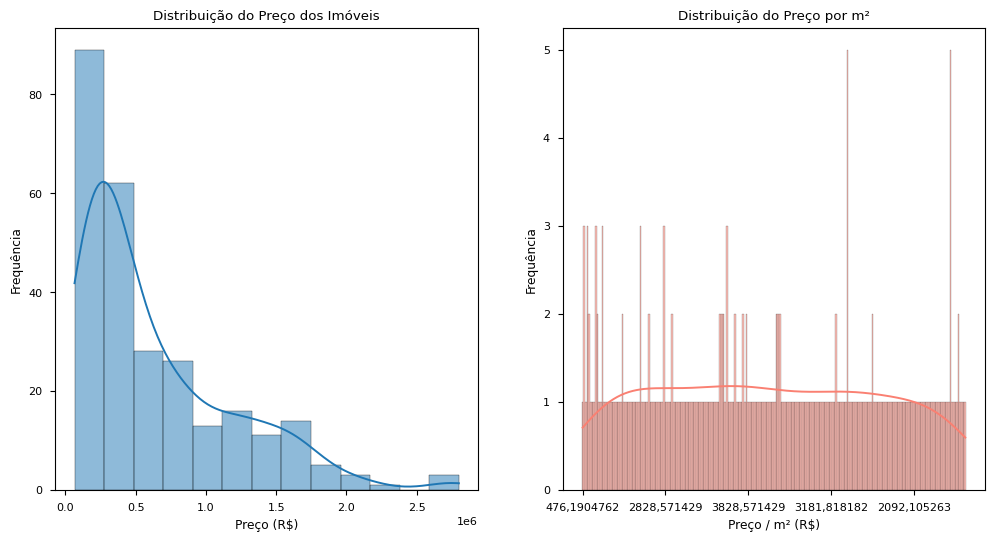

In [126]:
plt.style.use('seaborn-v0_8-paper')
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Histograma do Preço Total
sns.histplot(df['preco_brl'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Preço dos Imóveis')
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Frequência')

# Histograma do Preço/m²
ax = sns.histplot(df['preco_m2'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribuição do Preço por m²')
axes[1].set_xlabel('Preço / m² (R$)')
axes[1].set_ylabel('Frequência')
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
plt.savefig("distribuicao.pdf", format="pdf", bbox_inches='tight')

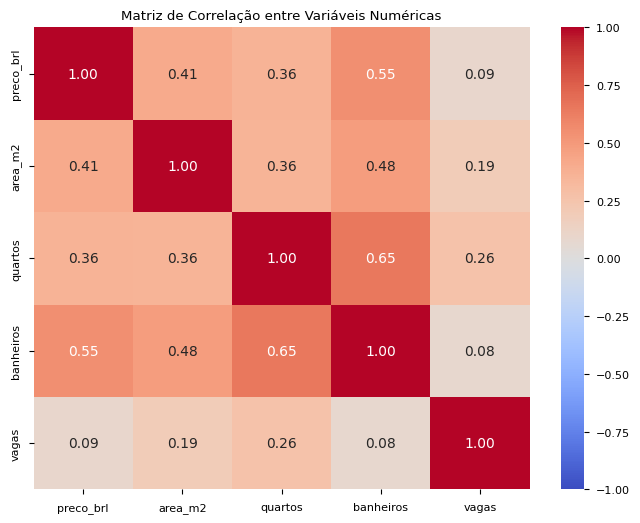

In [86]:
colunas_numericas = df.select_dtypes(include=[np.number])
matriz_corr = colunas_numericas.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.savefig("heatmap.pdf", format="pdf", bbox_inches='tight')

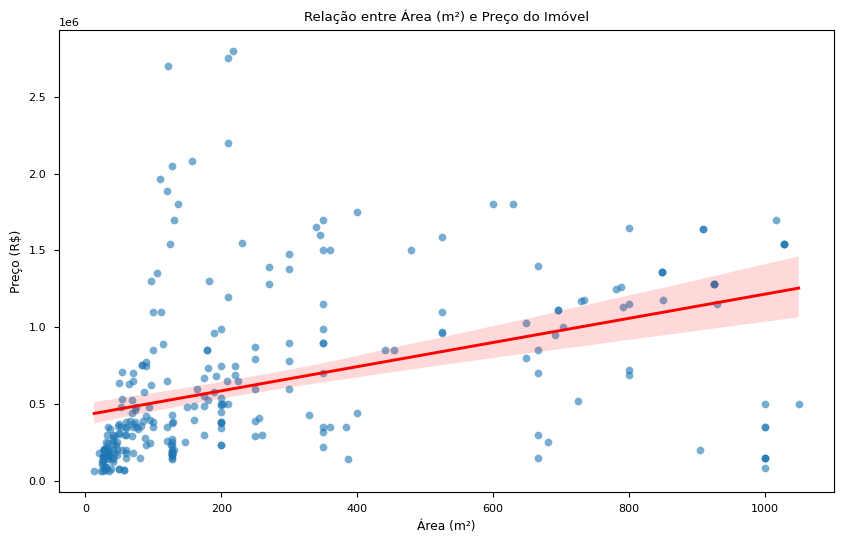

In [87]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='area_m2',
    y='preco_brl',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title('Relação entre Área (m²) e Preço do Imóvel')
plt.xlabel('Área (m²)')
plt.ylabel('Preço (R$)')
plt.savefig("regplot.pdf", format="pdf", bbox_inches='tight')

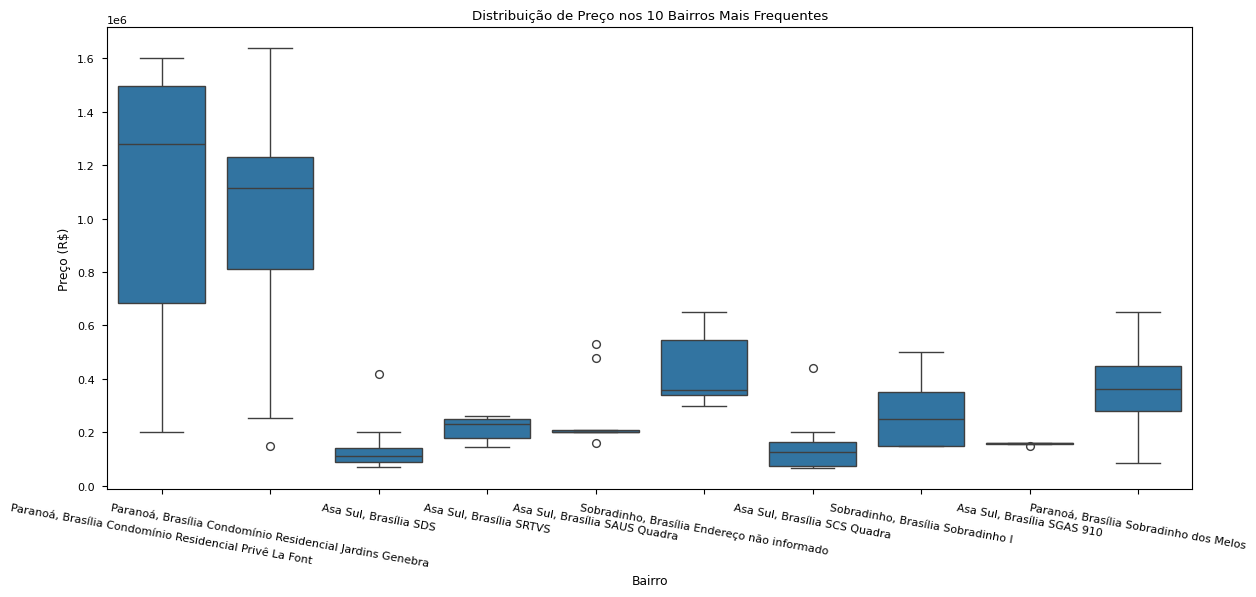

In [124]:
top_10_bairros = df['bairro'].value_counts().head(10).index
df_top10 = df[df['bairro'].isin(top_10_bairros)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top10,
    x='bairro',
    y='preco_brl',
    order=top_10_bairros
)
plt.title('Distribuição de Preço nos 10 Bairros Mais Frequentes')
plt.xlabel('Bairro')
plt.ylabel('Preço (R$)')
plt.xticks(rotation=350)
plt.savefig("boxplot.pdf", format="pdf", bbox_inches='tight')

In [89]:
features_base = ['area_m2', 'quartos', 'banheiros', 'vagas']

# Criando variáveis dummies para a coluna de bairro
df_model = pd.get_dummies(df, columns=['bairro'], drop_first=True)

bairro_cols = [col for col in df_model.columns if col.startswith('bairro_')]
X_cols = features_base + bairro_cols

X = df_model[X_cols]
y = df_model['preco_brl']

# Trata NaNs na variável alvo (y), se existirem
if y.isna().sum() > 0:
    idx_validos = y.dropna().index
    X = X.loc[idx_validos]
    y = y.loc[idx_validos]

# Divisão dos dados em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Estratégia 'median' preenche NaNs com a mediana de cada coluna
imputer = SimpleImputer(strategy='median')

# Ajusta e transforma nos dados de treino
X_train_imputed = imputer.fit_transform(X_train)

# Apenas transforma os dados de teste com a estatística calculada no treino
X_test_imputed = imputer.transform(X_test)

# Converte de volta para DataFrame mantendo os nomes das colunas
X_train_clean = pd.DataFrame(X_train_imputed, columns=X_cols, index=X_train.index)
X_test_clean = pd.DataFrame(X_test_imputed, columns=X_cols, index=X_test.index)

# A) Regressão Linear Múltipla
model_lr = LinearRegression()
model_lr.fit(X_train_clean, y_train)
y_pred_lr = model_lr.predict(X_test_clean)

# B) Regressão Linear com Transformação Logarítmica em preco
y_train_log = np.log(y_train)
model_log = LinearRegression()
model_log.fit(X_train_clean, y_train_log)
y_pred_log = np.exp(model_log.predict(X_test_clean))

# C) Ridge (Regularização L2)
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_clean, y_train)
y_pred_ridge = model_ridge.predict(X_test_clean)

# D) Lasso (Regularização L1)
model_lasso = Lasso(alpha=100.0, max_iter=10000)
model_lasso.fit(X_train_clean, y_train)
y_pred_lasso = model_lasso.predict(X_test_clean)

In [90]:
def calcular_metricas(y_true, y_pred, nome_modelo):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "Modelo": nome_modelo,
        "R²": f"{r2:.4f}",
        "MAE (R$)": f"R$ {mae:,.2f}",
        "RMSE (R$)": f"R$ {rmse:,.2f}"
    }

resultados = [
    calcular_metricas(y_test, y_pred_lr, "Regressão Linear Múltipla"),
    calcular_metricas(y_test, y_pred_log, "Regressão com log(preco)"),
    calcular_metricas(y_test, y_pred_ridge, "Ridge (L2)"),
    calcular_metricas(y_test, y_pred_lasso, "Lasso (L1)")
]

df_resultados = pd.DataFrame(resultados)
print("--- Comparativo de Desempenho dos Modelos ---")
print(df_resultados.to_string(index=False))

--- Comparativo de Desempenho dos Modelos ---
                   Modelo      R²      MAE (R$)     RMSE (R$)
Regressão Linear Múltipla  0.0478 R$ 295,818.65 R$ 489,003.82
 Regressão com log(preco) -0.0502 R$ 287,210.22 R$ 513,561.61
               Ridge (L2)  0.4535 R$ 251,031.87 R$ 370,451.60
               Lasso (L1)  0.2706 R$ 258,607.88 R$ 427,997.18
